# Part 2: Real-World GAN Applications

### Overview
This section extends GAN modelling to real-world datasets, focusing on learning complex image distributions. The aim is to evaluate how well GANs generalise beyond synthetic data and generate realistic samples in practical scenarios.
### Objective
To apply Deep Convolutional GANs (DCGANs) on real-world image data and assess their ability to generate high-quality, domain-relevant samples.

## Part 2.1: Blood Cell Microscope Imaging with MedMNIST

### Dataset
- Source: :contentReference[oaicite:0]{index=0}  
- Subset: **BloodMNIST**
- Data Type: Microscopic blood cell images (multi-class)

### Tasks Performed
- Loaded and explored the dataset (class distribution + sample visualisation)  
- Implemented a DCGAN using convolutional architectures  
- Trained generator and discriminator while tracking loss dynamics  
- Generated synthetic blood cell images  
- Compared real vs fake images visually and using metrics such as **FID**  
- Analysed the realism and limitations of generated samples  

### Key Insight
GAN performance on real-world medical imagery highlights challenges such as class variability, fine-grained texture generation, and training stability, making evaluation more complex than synthetic data scenarios.

In [1]:
# ============================================================
# CELL 1 — IMPORTS AND GLOBAL STYLING
# ============================================================
"""
Import the libraries needed for BloodMNIST loading, DCGAN training,
evaluation, and visualisation. The plotting style matches the rest of
the assignment and avoids blue shades across all saved figures.
"""

import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid

# Optional FID support
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    TORCHMETRICS_FID_AVAILABLE = True
except Exception:
    TORCHMETRICS_FID_AVAILABLE = False


# -----------------------------
# Global plotting style
# -----------------------------
COLORS = {
    "real": "#F4A261",        # warm orange
    "fake": "#E76F51",        # coral
    "loss_g": "#D81B60",      # pink
    "loss_d": "#F4B400",      # yellow-gold
    "bar": "#FB8500",         # orange
    "grid": "#D9D9D9",
    "text": "#3A3A3A"
}

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["grid.color"] = COLORS["grid"]
plt.rcParams["axes.labelcolor"] = COLORS["text"]
plt.rcParams["xtick.color"] = COLORS["text"]
plt.rcParams["ytick.color"] = COLORS["text"]
plt.rcParams["text.color"] = COLORS["text"]

In [2]:
# ============================================================
# CELL 2 — CONFIGURATION AND PROJECT PATHS
# ============================================================
"""
Store the BloodMNIST settings in one place and build the output structure
from the project root. Because the notebook is inside the Notebook folder,
the project root is taken as the parent directory.
"""

CONFIG_BLOOD = {
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # Dataset
    "data_file_name": "bloodmnist.npz",
    "image_size": 32,
    "num_channels": 3,
    "num_classes": 8,

    # Training
    "batch_size": 128,
    "z_dim": 100,
    "g_feature_maps": 64,
    "d_feature_maps": 64,
    "epochs": 40,
    "lr": 0.0002,
    "betas": (0.5, 0.999),

    # Evaluation and plotting
    "num_sample_grid": 64,
    "num_fid_samples": 1000,
    "snapshot_every": 10,
    "dpi": 300,
    "num_workers": 0
}

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name.lower() == "notebook" else NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "Data"
OUTPUTS_ROOT = PROJECT_ROOT / "Outputs"
PART2_OUTPUT_DIR = OUTPUTS_ROOT / "Part2_outputs"
BLOOD_OUTPUT_DIR = PART2_OUTPUT_DIR / "bloodmnist"
BLOOD_PLOTS_DIR = BLOOD_OUTPUT_DIR / "plots"
BLOOD_TABLES_DIR = BLOOD_OUTPUT_DIR / "tables"

BLOOD_DATA_PATH = DATA_DIR / CONFIG_BLOOD["data_file_name"]

for folder in [OUTPUTS_ROOT, PART2_OUTPUT_DIR, BLOOD_OUTPUT_DIR, BLOOD_PLOTS_DIR, BLOOD_TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

device = torch.device(CONFIG_BLOOD["device"])

# Small speed boost on CUDA
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print(f"Using device              : {device}")
print(f"Notebook directory        : {NOTEBOOK_DIR}")
print(f"Project root              : {PROJECT_ROOT}")
print(f"BloodMNIST data path      : {BLOOD_DATA_PATH}")
print(f"BloodMNIST plots folder   : {BLOOD_PLOTS_DIR}")
print(f"BloodMNIST tables folder  : {BLOOD_TABLES_DIR}")
print(f"FID available             : {TORCHMETRICS_FID_AVAILABLE}")

Using device              : cpu
Notebook directory        : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Notebook
Project root              : c:\Users\girid\OneDrive\Desktop\Generative modelling case study
BloodMNIST data path      : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Data\bloodmnist.npz
BloodMNIST plots folder   : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Outputs\Part2_outputs\bloodmnist\plots
BloodMNIST tables folder  : c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Outputs\Part2_outputs\bloodmnist\tables
FID available             : True


In [3]:
# ============================================================
# CELL 3 — REPRODUCIBILITY
# ============================================================
"""
Fix the random seed so the BloodMNIST experiment is reproducible. This
makes the training behaviour, image outputs, and final comparisons more
stable and easier to explain in the report.
"""

def set_seed(seed: int = 42) -> None:
    """
    Fix random seeds for reproducible BloodMNIST training.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG_BLOOD["seed"])

In [4]:
# ============================================================
# CELL 4 — FILE PATH HELPERS
# ============================================================
"""
Create helper functions for saving BloodMNIST plots and tables into the
correct folders. This keeps the main notebook cleaner and makes the
outputs easier to locate during report writing.
"""

def blood_plot_path(filename: str) -> Path:
    """
    Build the full path for a BloodMNIST plot file.
    """
    return BLOOD_PLOTS_DIR / filename


def blood_table_path(filename: str) -> Path:
    """
    Build the full path for a BloodMNIST table file.
    """
    return BLOOD_TABLES_DIR / filename

In [5]:
# ============================================================
# CELL 5 — LOAD THE BLOODMNIST DATA
# ============================================================
"""
Load the BloodMNIST NPZ file from the project Data folder and inspect the
main arrays. This confirms that the train, validation, and test splits
are available before visualisation or GAN training begins.
"""

from pathlib import Path
import numpy as np

# Set PROJECT ROOT (one level up from Notebook folder)
PROJECT_ROOT = Path.cwd().parent

# Construct correct path
BLOOD_DATA_PATH = PROJECT_ROOT / "Data" / "BloodMNIST" / "bloodmnist.npz"

# Debug check (optional but recommended)
print("Looking for file at:", BLOOD_DATA_PATH)

if not BLOOD_DATA_PATH.exists():
    raise FileNotFoundError(
        f"BloodMNIST file not found at: {BLOOD_DATA_PATH}\n"
        f"Expected location: {PROJECT_ROOT / 'Data' / 'BloodMNIST' / 'bloodmnist.npz'}"
    )

# Load dataset
blood_data = np.load(BLOOD_DATA_PATH)

train_images = blood_data["train_images"]
train_labels = blood_data["train_labels"].reshape(-1)

val_images = blood_data["val_images"]
val_labels = blood_data["val_labels"].reshape(-1)

test_images = blood_data["test_images"]
test_labels = blood_data["test_labels"].reshape(-1)

# Print dataset info
print("\n BloodMNIST loaded successfully.\n")
print("Train images:", train_images.shape, train_images.dtype)
print("Train labels:", train_labels.shape, train_labels.dtype)
print("Val images  :", val_images.shape, val_images.dtype)
print("Val labels  :", val_labels.shape, val_labels.dtype)
print("Test images :", test_images.shape, test_images.dtype)
print("Test labels :", test_labels.shape, test_labels.dtype)

# Class names
BLOOD_CLASS_NAMES = {
    0: "basophil",
    1: "eosinophil",
    2: "erythroblast",
    3: "immature granulocytes",
    4: "lymphocyte",
    5: "monocyte",
    6: "neutrophil",
    7: "platelet"
}

print("\nClass mapping:")
for class_id, class_name in BLOOD_CLASS_NAMES.items():
    print(f"{class_id}: {class_name}")

Looking for file at: c:\Users\girid\OneDrive\Desktop\Generative modelling case study\Data\BloodMNIST\bloodmnist.npz

 BloodMNIST loaded successfully.

Train images: (11959, 28, 28, 3) uint8
Train labels: (11959,) uint8
Val images  : (1712, 28, 28, 3) uint8
Val labels  : (1712,) uint8
Test images : (3421, 28, 28, 3) uint8
Test labels : (3421,) uint8

Class mapping:
0: basophil
1: eosinophil
2: erythroblast
3: immature granulocytes
4: lymphocyte
5: monocyte
6: neutrophil
7: platelet


In [6]:
# ============================================================
# CELL 6 — DATASET OVERVIEW TABLE
# ============================================================
"""
Create a compact dataset overview table so the split sizes and image
dimensions are clearly documented. This will help later when writing the
methodology and dataset description in the report.
"""

dataset_overview = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "num_images": [len(train_images), len(val_images), len(test_images)],
    "image_height": [train_images.shape[1], val_images.shape[1], test_images.shape[1]],
    "image_width": [train_images.shape[2], val_images.shape[2], test_images.shape[2]],
    "channels": [train_images.shape[3], val_images.shape[3], test_images.shape[3]]
})

dataset_overview.to_csv(blood_table_path("p2_01_blood_dataset_overview.csv"), index=False)
print(dataset_overview)

        split  num_images  image_height  image_width  channels
0       train       11959            28           28         3
1  validation        1712            28           28         3
2        test        3421            28           28         3


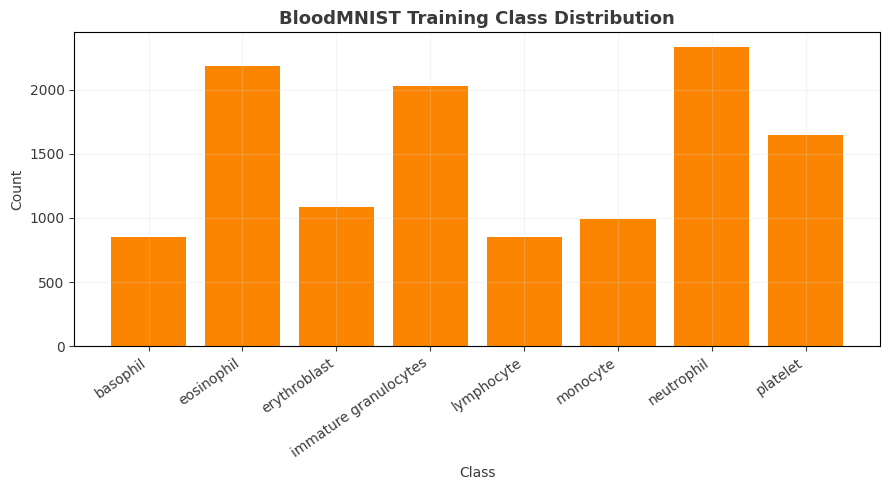

   class_id             class_name  count
0         0               basophil    852
1         1             eosinophil   2181
2         2           erythroblast   1085
3         3  immature granulocytes   2026
4         4             lymphocyte    849
5         5               monocyte    993
6         6             neutrophil   2330
7         7               platelet   1643


In [7]:
# ============================================================
# CELL 7 — CLASS DISTRIBUTION ANALYSIS
# ============================================================
"""
Inspect the class balance in the BloodMNIST training split. This gives a
clear picture of the available blood cell categories and shows whether
the training data is balanced or skewed across classes.
"""

train_class_counts = pd.Series(train_labels).value_counts().sort_index()

train_class_distribution = pd.DataFrame({
    "class_id": train_class_counts.index,
    "class_name": [BLOOD_CLASS_NAMES.get(i, f"class_{i}") for i in train_class_counts.index],
    "count": train_class_counts.values
})

train_class_distribution.to_csv(
    blood_table_path("p2_02_blood_train_class_distribution.csv"),
    index=False
)

plt.figure(figsize=(9, 5))
plt.bar(
    train_class_distribution["class_name"],
    train_class_distribution["count"],
    color=COLORS["bar"]
)
plt.title("BloodMNIST Training Class Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(blood_plot_path("p2_01_blood_train_class_distribution.png"), dpi=CONFIG_BLOOD["dpi"], bbox_inches="tight")
plt.show()

print(train_class_distribution)

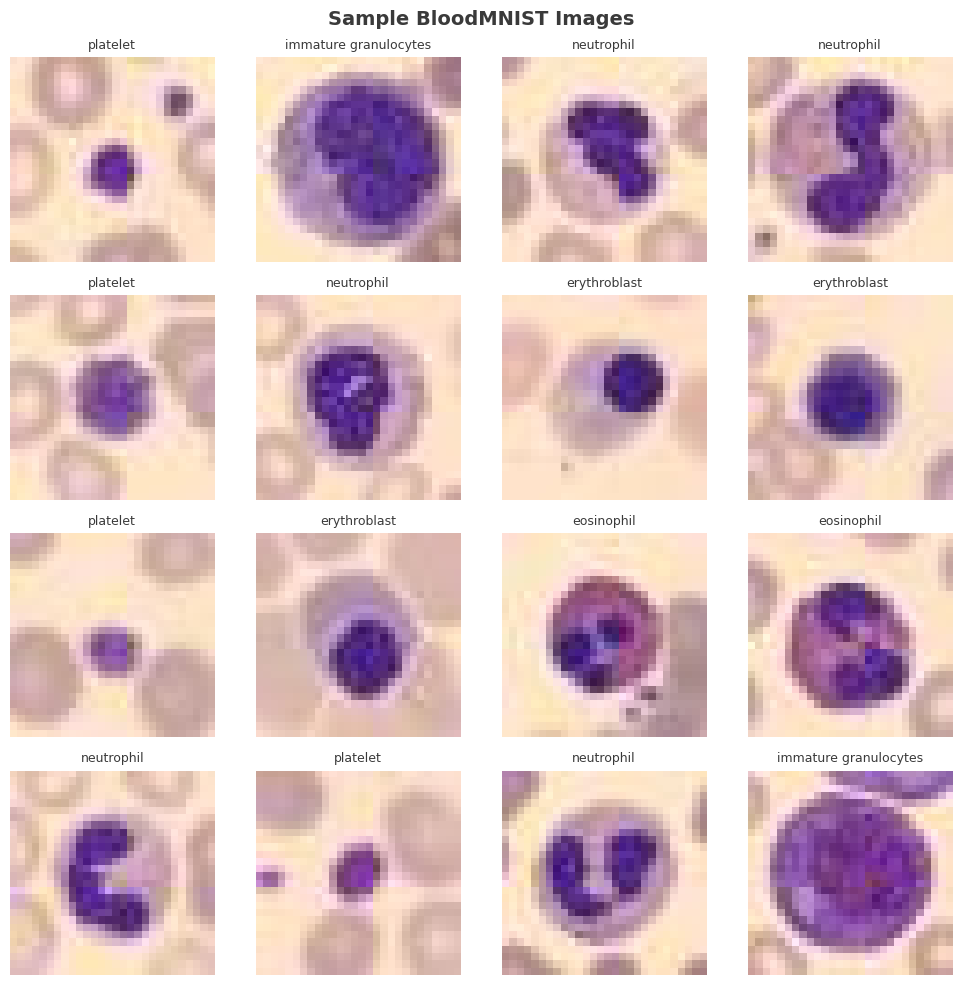

In [8]:
# ============================================================
# CELL 8 — REAL IMAGE SAMPLE GRID
# ============================================================
"""
Display a grid of real BloodMNIST images to understand the visual style
of the dataset. This gives a useful baseline view of the microscope
images before training the DCGAN.
"""

def show_image_grid(images: np.ndarray, labels: np.ndarray, n_rows: int = 4, n_cols: int = 4) -> None:
    """
    Show a grid of real BloodMNIST images with class labels.
    """
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.set_title(BLOOD_CLASS_NAMES.get(int(labels[i]), f"class_{int(labels[i])}"), fontsize=9)
        ax.axis("off")

    plt.suptitle("Sample BloodMNIST Images", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(blood_plot_path("p2_02_blood_real_sample_grid.png"), dpi=CONFIG_BLOOD["dpi"], bbox_inches="tight")
    plt.show()

show_image_grid(train_images, train_labels, n_rows=4, n_cols=4)

In [9]:
# ============================================================
# CELL 9 — DATASET CLASS AND DATALOADERS
# ============================================================
"""
Prepare a PyTorch dataset and dataloaders for BloodMNIST. The images are
resized from 28x28 to 32x32 and normalised to [-1, 1] so they match the
expected input and output range of the DCGAN.
"""

class BloodMNISTDataset(Dataset):
    """
    Create a PyTorch dataset for BloodMNIST images and labels.
    """
    def __init__(self, images: np.ndarray, labels: np.ndarray, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = int(self.labels[idx])

        image = Image.fromarray(image)

        if self.transform is not None:
            image = self.transform(image)

        return image, label


image_transform = transforms.Compose([
    transforms.Resize((CONFIG_BLOOD["image_size"], CONFIG_BLOOD["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = BloodMNISTDataset(train_images, train_labels, transform=image_transform)
val_dataset = BloodMNISTDataset(val_images, val_labels, transform=image_transform)
test_dataset = BloodMNISTDataset(test_images, test_labels, transform=image_transform)

pin_memory_flag = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG_BLOOD["batch_size"],
    shuffle=True,
    num_workers=CONFIG_BLOOD["num_workers"],
    pin_memory=pin_memory_flag
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG_BLOOD["batch_size"],
    shuffle=False,
    num_workers=CONFIG_BLOOD["num_workers"],
    pin_memory=pin_memory_flag
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG_BLOOD["batch_size"],
    shuffle=False,
    num_workers=CONFIG_BLOOD["num_workers"],
    pin_memory=pin_memory_flag
)

sample_batch, sample_batch_labels = next(iter(train_loader))
print("Batch shape:", sample_batch.shape)
print("Batch label shape:", sample_batch_labels.shape)

Batch shape: torch.Size([128, 3, 32, 32])
Batch label shape: torch.Size([128])


In [10]:
# ============================================================
# CELL 10 — DCGAN MODEL DEFINITIONS
# ============================================================
"""
Define the generator and discriminator for the BloodMNIST DCGAN. A
convolutional GAN is appropriate here because BloodMNIST consists of
RGB microscope images with local texture and spatial structure.
"""

class BloodGenerator(nn.Module):
    """
    Build the DCGAN generator for 32x32 RGB BloodMNIST images.
    """
    def __init__(self, z_dim=100, feature_maps=64, img_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, feature_maps * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps),
            nn.ReLU(True),

            nn.ConvTranspose2d(feature_maps, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class BloodDiscriminator(nn.Module):
    """
    Build the DCGAN discriminator for 32x32 RGB BloodMNIST images.
    """
    def __init__(self, feature_maps=64, img_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, feature_maps, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(feature_maps * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


def weights_init(module):
    """
    Apply standard DCGAN-style weight initialisation.
    """
    classname = module.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0)

In [11]:
# ============================================================
# CELL 11 — TRAINING AND VISUALISATION HELPERS
# ============================================================
"""
Create helper functions for image denormalisation, latent sampling, loss
plotting, and saved image grids. These keep the training code simpler
and make the outputs easier to reuse later in the report.
"""

def denormalise_images(x: torch.Tensor) -> torch.Tensor:
    """
    Convert images from [-1, 1] back to [0, 1] for display and saving.
    """
    return (x + 1) / 2


def sample_latent(batch_size: int, z_dim: int, device: torch.device) -> torch.Tensor:
    """
    Sample latent noise vectors for the generator.
    """
    return torch.randn(batch_size, z_dim, 1, 1, device=device)


def save_generated_grid(
    generator: nn.Module,
    fixed_noise: torch.Tensor,
    filename: str,
    title: str = None,
    show_plot: bool = True
) -> None:
    """
    Save a grid of generated BloodMNIST images from fixed latent noise.
    The plot can be shown or only saved, depending on where it is used.
    """
    generator.eval()
    with torch.no_grad():
        fake_images = generator(fixed_noise).cpu()

    grid = make_grid(denormalise_images(fake_images), nrow=8, padding=2)

    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    if title is not None:
        plt.title(title, fontsize=13, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(blood_plot_path(filename), dpi=CONFIG_BLOOD["dpi"], bbox_inches="tight")
    if show_plot:
        plt.show()
    else:
        plt.close()


def save_real_batch_grid(dataloader: DataLoader, filename: str) -> None:
    """
    Save and display a grid of real preprocessed BloodMNIST images.
    """
    real_batch, _ = next(iter(dataloader))
    grid = make_grid(denormalise_images(real_batch[:64]), nrow=8, padding=2)

    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.title("Real BloodMNIST Images", fontsize=13, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(blood_plot_path(filename), dpi=CONFIG_BLOOD["dpi"], bbox_inches="tight")
    plt.show()


def save_loss_plot(g_losses: list, d_losses: list, filename: str) -> None:
    """
    Save and display the BloodMNIST generator and discriminator loss curves.
    """
    plt.figure(figsize=(8, 4))
    plt.plot(g_losses, color=COLORS["loss_g"], linewidth=2.2, label="Generator Loss")
    plt.plot(d_losses, color=COLORS["loss_d"], linewidth=2.2, label="Discriminator Loss")
    plt.title("BloodMNIST DCGAN Loss Curves", fontsize=13, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(blood_plot_path(filename), dpi=CONFIG_BLOOD["dpi"], bbox_inches="tight")
    plt.show()

In [12]:
# ============================================================
# CELL 12 — INITIALISE MODELS, OPTIMISERS, AND FIXED NOISE
# ============================================================
"""
Initialise the BloodMNIST DCGAN, apply weight initialisation, and prepare
the optimisers and fixed latent vectors. The fixed noise is reused across
epochs so the generator’s progress can be compared consistently.
"""

generator = BloodGenerator(
    z_dim=CONFIG_BLOOD["z_dim"],
    feature_maps=CONFIG_BLOOD["g_feature_maps"],
    img_channels=CONFIG_BLOOD["num_channels"]
).to(device)

discriminator = BloodDiscriminator(
    feature_maps=CONFIG_BLOOD["d_feature_maps"],
    img_channels=CONFIG_BLOOD["num_channels"]
).to(device)

generator.apply(weights_init)
discriminator.apply(weights_init)

criterion = nn.BCELoss()

optimizer_g = optim.Adam(generator.parameters(), lr=CONFIG_BLOOD["lr"], betas=CONFIG_BLOOD["betas"])
optimizer_d = optim.Adam(discriminator.parameters(), lr=CONFIG_BLOOD["lr"], betas=CONFIG_BLOOD["betas"])

fixed_noise = sample_latent(CONFIG_BLOOD["num_sample_grid"], CONFIG_BLOOD["z_dim"], device)

g_losses = []
d_losses = []

In [13]:
# ============================================================
# CELL 13 — DCGAN TRAINING LOOP
# ============================================================
"""
Train the BloodMNIST DCGAN and record the generator and discriminator
losses over time. To keep the notebook faster, training snapshots are
saved during training but only the final key plots are displayed later.
"""

for epoch in range(CONFIG_BLOOD["epochs"]):
    generator.train()
    discriminator.train()

    g_epoch_loss = 0.0
    d_epoch_loss = 0.0

    for real_images, _ in train_loader:
        real_images = real_images.to(device, non_blocking=True)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # -------------------------
        # Train discriminator
        # -------------------------
        discriminator.zero_grad(set_to_none=True)

        real_output = discriminator(real_images)
        d_loss_real = criterion(real_output, real_labels)

        noise = sample_latent(batch_size, CONFIG_BLOOD["z_dim"], device)
        fake_images = generator(noise)
        fake_output = discriminator(fake_images.detach())
        d_loss_fake = criterion(fake_output, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_d.step()

        # -------------------------
        # Train generator
        # -------------------------
        generator.zero_grad(set_to_none=True)

        noise = sample_latent(batch_size, CONFIG_BLOOD["z_dim"], device)
        fake_images = generator(noise)
        fake_output = discriminator(fake_images)

        g_loss = criterion(fake_output, real_labels)
        g_loss.backward()
        optimizer_g.step()

        g_epoch_loss += g_loss.item()
        d_epoch_loss += d_loss.item()

    g_losses.append(g_epoch_loss / len(train_loader))
    d_losses.append(d_epoch_loss / len(train_loader))

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1:>2}/{CONFIG_BLOOD['epochs']}] "
            f"| D Loss: {d_losses[-1]:.4f} "
            f"| G Loss: {g_losses[-1]:.4f}"
        )

    # Save snapshots less often to reduce notebook overhead
    if (epoch + 1) % CONFIG_BLOOD["snapshot_every"] == 0 or (epoch + 1) == CONFIG_BLOOD["epochs"]:
        save_generated_grid(
            generator=generator,
            fixed_noise=fixed_noise,
            filename=f"p2_03_blood_generated_grid_epoch_{epoch+1:02d}.png",
            title=f"Generated BloodMNIST Samples — Epoch {epoch+1}",
            show_plot=False
        )

training_history_blood = pd.DataFrame({
    "epoch": np.arange(1, CONFIG_BLOOD["epochs"] + 1),
    "generator_loss": g_losses,
    "discriminator_loss": d_losses
})
training_history_blood.to_csv(blood_table_path("p2_03_blood_training_history.csv"), index=False)

print("BloodMNIST training complete.")

Epoch [ 1/40] | D Loss: 0.4242 | G Loss: 4.9982
Epoch [ 5/40] | D Loss: 0.8319 | G Loss: 2.2573
Epoch [10/40] | D Loss: 0.9170 | G Loss: 1.8388
Epoch [15/40] | D Loss: 0.9368 | G Loss: 1.7976
Epoch [20/40] | D Loss: 0.8824 | G Loss: 1.7674
Epoch [25/40] | D Loss: 0.7957 | G Loss: 2.0162
Epoch [30/40] | D Loss: 0.6840 | G Loss: 2.1415
Epoch [35/40] | D Loss: 0.6335 | G Loss: 2.2714
Epoch [40/40] | D Loss: 0.5463 | G Loss: 2.4864
BloodMNIST training complete.


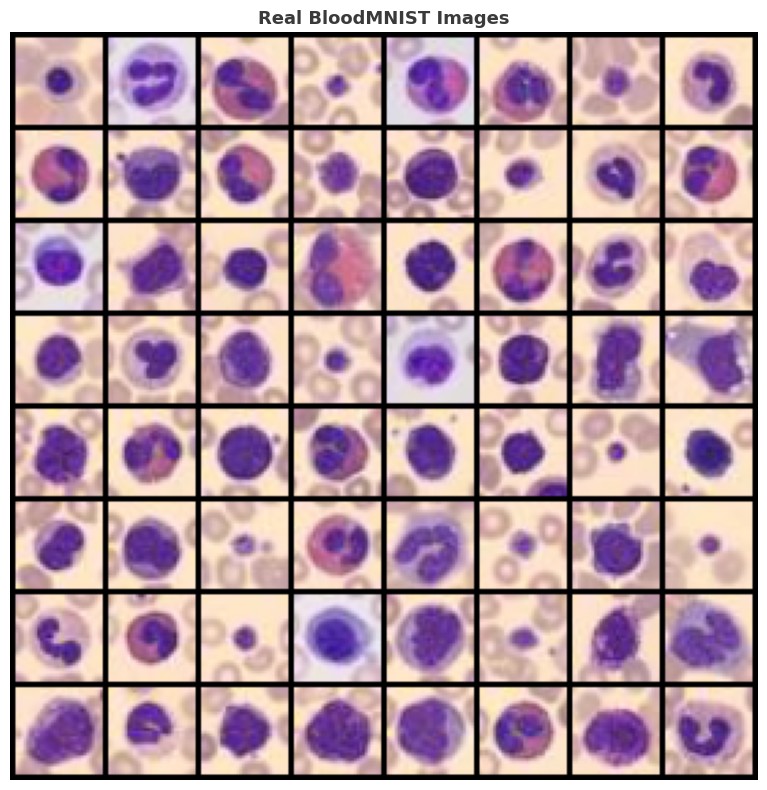

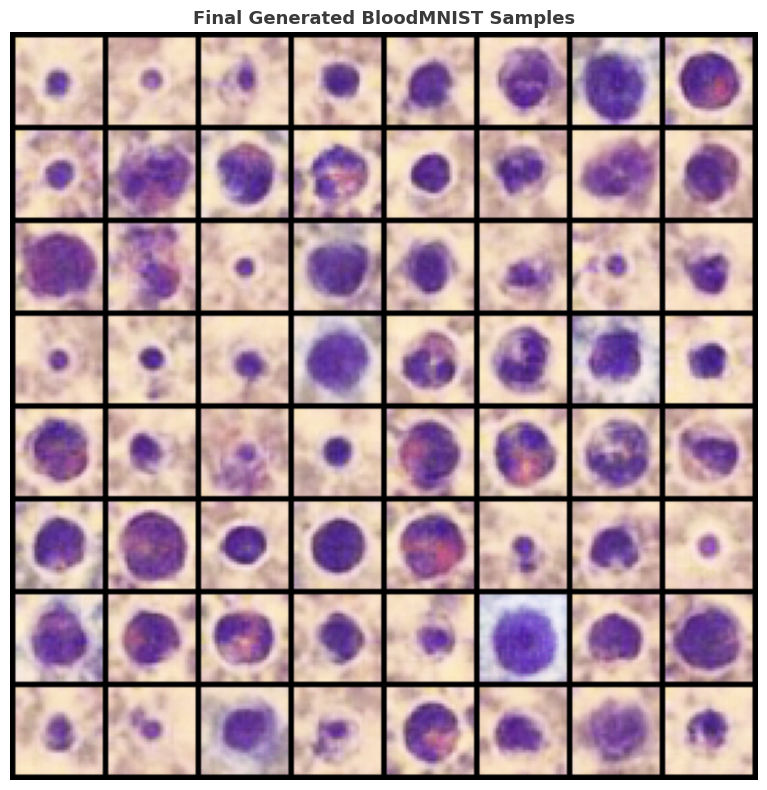

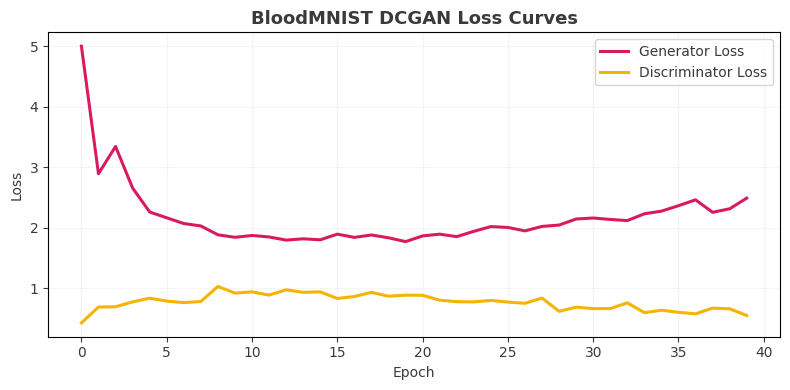

In [14]:
# ============================================================
# CELL 14 — SAVE AND DISPLAY THE MAIN FINAL PLOTS
# ============================================================
"""
Save and display the main final BloodMNIST outputs. This includes the real
image grid, final generated image grid, and loss curves that are most
useful for the report and final evaluation.
"""

save_real_batch_grid(
    dataloader=train_loader,
    filename="p2_04_blood_real_image_grid.png"
)

save_generated_grid(
    generator=generator,
    fixed_noise=fixed_noise,
    filename="p2_05_blood_final_generated_image_grid.png",
    title="Final Generated BloodMNIST Samples",
    show_plot=True
)

save_loss_plot(
    g_losses=g_losses,
    d_losses=d_losses,
    filename="p2_06_blood_loss_curves.png"
)

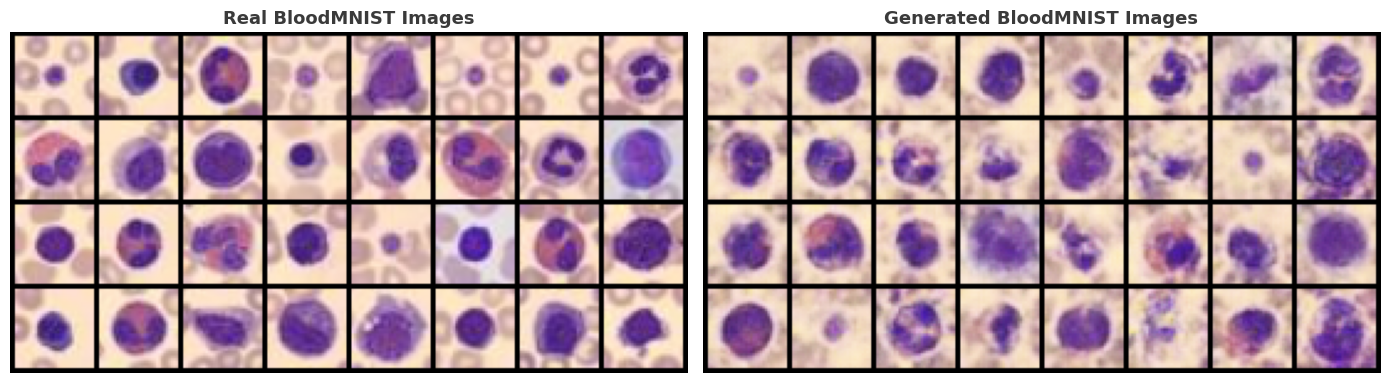

In [15]:
# ============================================================
# CELL 15 — REAL VS GENERATED SIDE-BY-SIDE COMPARISON
# ============================================================
"""
Create a side-by-side comparison between real and generated BloodMNIST
images. This is one of the clearest figures to include in the report
because it directly shows the visual quality of the synthetic samples.
"""

# Get a small batch of real images for comparison
real_batch, _ = next(iter(train_loader))
real_vis = denormalise_images(real_batch[:32]).cpu()

# Generate a matching number of fake images
generator.eval()
with torch.no_grad():
    fake_vis = denormalise_images(
        generator(sample_latent(32, CONFIG_BLOOD["z_dim"], device))
    ).cpu()

# Create grid layouts for cleaner comparison
real_grid = make_grid(real_vis, nrow=8, padding=2)
fake_grid = make_grid(fake_vis, nrow=8, padding=2)

# Plot side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor("white")

axes[0].imshow(np.transpose(real_grid.numpy(), (1, 2, 0)))
axes[0].set_title("Real BloodMNIST Images", fontsize=13, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(np.transpose(fake_grid.numpy(), (1, 2, 0)))
axes[1].set_title("Generated BloodMNIST Images", fontsize=13, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(
    blood_plot_path("p2_07_blood_real_vs_generated_comparison.png"),
    dpi=CONFIG_BLOOD["dpi"],
    bbox_inches="tight"
)
plt.show()

In [16]:
# ============================================================
# CELL 16 — FID EVALUATION
# ============================================================
"""
Compute an FID score to compare real and generated BloodMNIST images in
feature space. A subsample is used for speed, and the result is saved as
a small table for later inclusion in the report.
"""

fid_results = []

if TORCHMETRICS_FID_AVAILABLE:
    try:
        fid_metric = FrechetInceptionDistance(feature=2048).to(device)

        num_fid = CONFIG_BLOOD["num_fid_samples"]

        # ----------------------------------------------------
        # Collect real images from the test loader
        # ----------------------------------------------------
        real_images_for_fid = []
        total_real = 0

        for images, _ in test_loader:
            real_images_for_fid.append(images)
            total_real += images.size(0)

            if total_real >= num_fid:
                break

        real_images_for_fid = torch.cat(real_images_for_fid, dim=0)[:num_fid]

        # ----------------------------------------------------
        # Generate fake images
        # ----------------------------------------------------
        fake_images_for_fid = []
        generator.eval()

        with torch.no_grad():
            remaining = num_fid
            while remaining > 0:
                current_batch = min(CONFIG_BLOOD["batch_size"], remaining)
                z = sample_latent(current_batch, CONFIG_BLOOD["z_dim"], device)
                fake_batch = generator(z).cpu()
                fake_images_for_fid.append(fake_batch)
                remaining -= current_batch

        fake_images_for_fid = torch.cat(fake_images_for_fid, dim=0)[:num_fid]

        # ----------------------------------------------------
        # Convert from [-1, 1] to uint8 [0, 255]
        # Torchmetrics FID expects uint8 images in [0, 255]
        # ----------------------------------------------------
        real_uint8 = (
            denormalise_images(real_images_for_fid)
            .mul(255)
            .clamp(0, 255)
            .to(torch.uint8)
            .to(device)
        )

        fake_uint8 = (
            denormalise_images(fake_images_for_fid)
            .mul(255)
            .clamp(0, 255)
            .to(torch.uint8)
            .to(device)
        )

        # ----------------------------------------------------
        # Compute FID
        # ----------------------------------------------------
        fid_metric.update(real_uint8, real=True)
        fid_metric.update(fake_uint8, real=False)
        fid_score = float(fid_metric.compute().item())

        fid_results.append({
            "metric": "FID",
            "value": fid_score,
            "num_real_images": num_fid,
            "num_fake_images": num_fid,
            "status": "computed_successfully"
        })

        print(f"BloodMNIST FID: {fid_score:.4f}")

    except Exception as e:
        print("FID computation failed:", str(e))

        fid_results.append({
            "metric": "FID",
            "value": np.nan,
            "num_real_images": 0,
            "num_fake_images": 0,
            "status": f"failed: {str(e)}"
        })

else:
    print("torchmetrics FID is not available in this environment.")

    fid_results.append({
        "metric": "FID",
        "value": np.nan,
        "num_real_images": 0,
        "num_fake_images": 0,
        "status": "torchmetrics_fid_not_available"
    })

fid_results_df = pd.DataFrame(fid_results)
fid_results_df.to_csv(
    blood_table_path("p2_04_blood_fid_results.csv"),
    index=False
)

print(fid_results_df)

BloodMNIST FID: 210.6532
  metric       value  num_real_images  num_fake_images                 status
0    FID  210.653183             1000             1000  computed_successfully


In [17]:
# ============================================================
# CELL 17 — COMPACT EXPERIMENT SUMMARY TABLE
# ============================================================
"""
Create one compact summary table with the final BloodMNIST settings and
main results. This gives a clean numerical record of the experiment
without overcrowding the report with too many separate tables.
"""

final_fid_value = (
    fid_results_df["value"].iloc[0]
    if "value" in fid_results_df.columns else np.nan
)

final_fid_status = (
    fid_results_df["status"].iloc[0]
    if "status" in fid_results_df.columns else "unknown"
)

blood_summary = pd.DataFrame({
    "item": [
        "train_images",
        "val_images",
        "test_images",
        "image_size_after_resize",
        "epochs",
        "batch_size",
        "latent_dim",
        "final_generator_loss",
        "final_discriminator_loss",
        "fid_value",
        "fid_status",
        "device_used"
    ],
    "value": [
        len(train_images),
        len(val_images),
        len(test_images),
        CONFIG_BLOOD["image_size"],
        CONFIG_BLOOD["epochs"],
        CONFIG_BLOOD["batch_size"],
        CONFIG_BLOOD["z_dim"],
        g_losses[-1],
        d_losses[-1],
        final_fid_value,
        final_fid_status,
        str(device)
    ]
})

blood_summary.to_csv(
    blood_table_path("p2_05_blood_experiment_summary.csv"),
    index=False
)

print(blood_summary)

                        item                  value
0               train_images                  11959
1                 val_images                   1712
2                test_images                   3421
3    image_size_after_resize                     32
4                     epochs                     40
5                 batch_size                    128
6                 latent_dim                    100
7       final_generator_loss               2.486429
8   final_discriminator_loss               0.546274
9                  fid_value             210.653183
10                fid_status  computed_successfully
11               device_used                    cpu
